#**Modelado Predictivo de Morosidad Bancaria Mediante LightGBM con Soporte de Inteligencia Artificial Generativa**

##**DATA: Home Credit Default Risk (KAGGLE)**

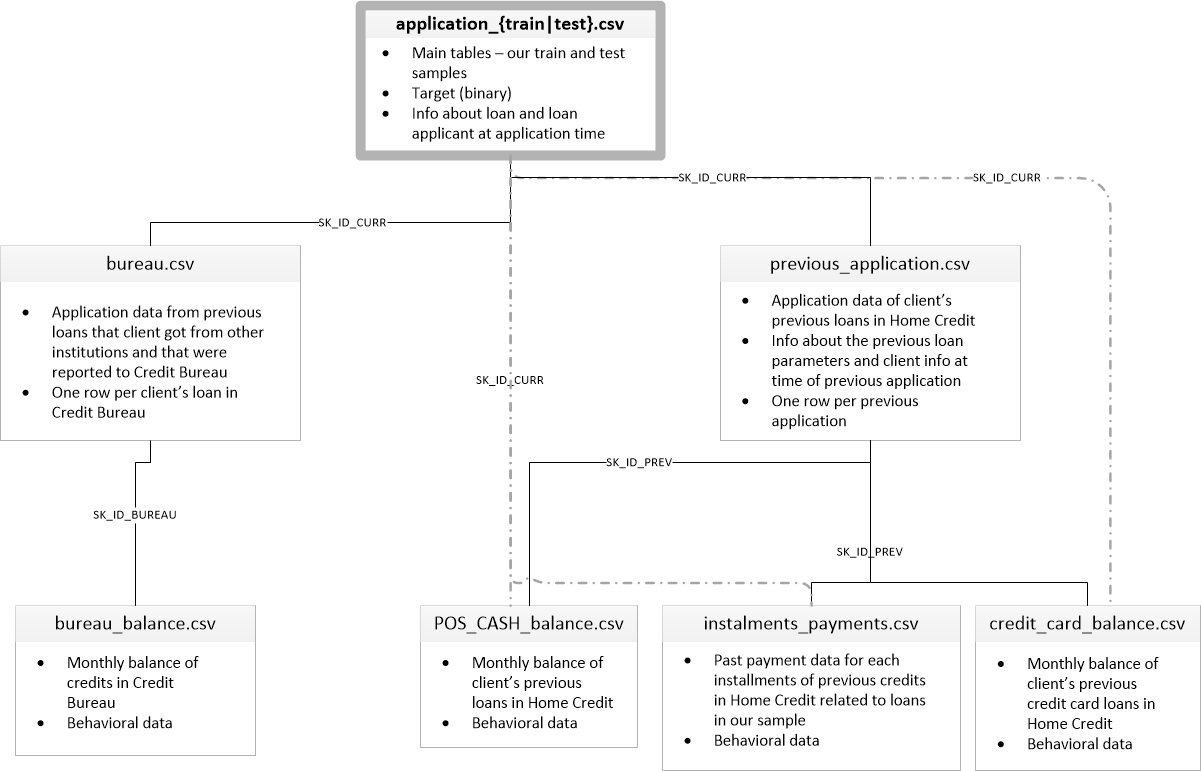

In [1]:
!wget https://raw.githubusercontent.com/AnghieLizzeth22/rag_ml_sistfinanciero/refs/heads/construccion/funciones/DiagnosticoUnivariado.py

--2026-05-24 23:23:05--  https://raw.githubusercontent.com/AnghieLizzeth22/rag_ml_sistfinanciero/refs/heads/construccion/funciones/DiagnosticoUnivariado.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2898 (2.8K) [text/plain]
Saving to: ‘DiagnosticoUnivariado.py’

DiagnosticoUnivaria 100%[===================>]   2.83K  --.-KB/s    in 0s      

2026-05-24 23:23:05 (45.4 MB/s) - ‘DiagnosticoUnivariado.py’ saved [2898/2898]



In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from google.colab import drive
import joblib
import os
import glob
import gc

from DiagnosticoUnivariado import DiagnosticoUnivariado, variables_categoricas, variables_numericas, grap_variable_vs_target

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, mean_absolute_percentage_error, log_loss, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

import warnings
warnings.filterwarnings('ignore')
print("✅ Entorno configurado y librerías importadas.")

✅ Entorno configurado y librerías importadas.


# **1. Carga y entendimiento de los datos**

## **1.1. Ingesta**

In [4]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/Maestría/CICLO II/Proyecto Integrador/data/'

# Función para cargar todo automáticamente
def load_all_datasets(directory):
    data_dict = {}
    files = glob.glob(os.path.join(directory, "*.csv"))

    print(f"Buscando archivos en: {directory}\n")

    for f in files:
        file_name = os.path.basename(f).split('.')[0]
        print(f"Cargando {file_name}...")

        try:
            # Intento normal (UTF-8)
            data_dict[file_name] = pd.read_csv(f)
        except UnicodeDecodeError:
            # Si falla, intentamos con latin-1
            print(f"  ⚠️ Reintentando {file_name} con encoding 'latin-1'...")
            data_dict[file_name] = pd.read_csv(f, encoding='latin-1')

    print("\n✅ ¡Todos los archivos han sido cargados correctamente!")
    return data_dict

datasets = load_all_datasets(folder_path)

Mounted at /content/drive
Buscando archivos en: /content/drive/MyDrive/Maestría/CICLO II/Proyecto Integrador/data/

Cargando HomeCredit_columns_description...
  ⚠️ Reintentando HomeCredit_columns_description con encoding 'latin-1'...
Cargando application_test...
Cargando POS_CASH_balance...
Cargando application_train...
Cargando bureau...
Cargando bureau_balance...
Cargando credit_card_balance...
Cargando installments_payments...
Cargando sample_submission...
Cargando previous_application...

✅ ¡Todos los archivos han sido cargados correctamente!


In [5]:
# Desempaquetado de tablas principales
df_original_train = datasets.get('application_train') # El archivo base con TARGET
bureau = datasets.get('bureau')
bureau_balance = datasets.get('bureau_balance')
previous_application = datasets.get('previous_application')
installments_payments = datasets.get('installments_payments')
POS_CASH_balance = datasets.get('POS_CASH_balance')
credit_card_balance = datasets.get('credit_card_balance')

print("✂️ Separando la data base en Train (80%) y Test Local (20%)...")

# Separamos el dataframe de aplicación original antes de cualquier análisis
train_base, test_base = train_test_split(
    df_original_train,
    test_size=0.2,
    random_state=42,
    stratify=df_original_train['TARGET']
)

train = train_base.copy()
test = test_base.copy()

print(f"✅ Data de entrenamiento para EDA y Modelado (train): {train.shape}")
print(f"✅ Data de prueba - test: {test_base.shape}")

✂️ Separando la data base en Train (80%) y Test Local (20%)...
✅ Data de entrenamiento para EDA y Modelado (train): (246008, 122)
✅ Data de prueba - test: (61503, 122)


In [6]:
print("📐 DIMENSIONES DE TODAS LAS TABLAS CARGADAS:")
print("-" * 50)

tablas_monitoreo = {
    'Application Train (Base)': train,
    'Application Test': test,
    'Bureau (Créditos Externos)': bureau,
    'Bureau Balance (Historial Ext)': bureau_balance,
    'Previous Application (Internos)': previous_application,
    'Installments Payments (Pagos)': installments_payments,
    'POS CASH Balance (Consumo)': POS_CASH_balance,
    'Credit Card Balance (Tarjetas)': credit_card_balance
}

for nombre, df in tablas_monitoreo.items():
    if df is not None:
        # Corregido: Usamos ':,' para el formato limpio con separador de miles
        print(f"🔹 {nombre:<32} : {df.shape[0]:,} filas | {df.shape[1]} columnas")
    else:
        print(f"❌ {nombre:<32} : [ERROR] Archivo no encontrado en Drive")
print("-" * 50)

📐 DIMENSIONES DE TODAS LAS TABLAS CARGADAS:
--------------------------------------------------
🔹 Application Train (Base)         : 246,008 filas | 122 columnas
🔹 Application Test                 : 61,503 filas | 122 columnas
🔹 Bureau (Créditos Externos)       : 1,716,428 filas | 17 columnas
🔹 Bureau Balance (Historial Ext)   : 27,299,925 filas | 3 columnas
🔹 Previous Application (Internos)  : 1,670,214 filas | 37 columnas
🔹 Installments Payments (Pagos)    : 13,605,401 filas | 8 columnas
🔹 POS CASH Balance (Consumo)       : 10,001,358 filas | 8 columnas
🔹 Credit Card Balance (Tarjetas)   : 3,840,312 filas | 23 columnas
--------------------------------------------------


In [7]:
# Clean the /content/drive directory by removing its contents
# !rm -rf /content/drive/MyDrive
# print('Contents of /content/drive removed. You can now try mounting Google Drive again.')

In [8]:
# print('Listing contents of /content/drive:')
# !ls -la /content/drive

## **1.2. Diagnóstico EDA**

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Paleta de colores
PALETA_BANCO = ["#1f4e79", "#d9534f", "#5cb85c", "#f0ad4e"]

### **1.2.1 Diagnóstico de la Estructura Relacional**

In [10]:
print("🔍 REPORTE DE SALUD DE TABLAS PERIFÉRICAS:")
print("-" * 65)
print(f"{'Tabla':<25} | {'Nulos Promedio':<15} | {'Variables Útiles'}")
print("-" * 65)

tablas_secundarias = {
    'Bureau': bureau,
    'Prev. Applications': previous_application,
    'Installments': installments_payments,
    'POS Cash': POS_CASH_balance,
    'Credit Card': credit_card_balance
}

for nombre, df_sec in tablas_secundarias.items():
    if df_sec is not None:
        # Calcula el porcentaje promedio de datos faltantes en toda la tabla
        pct_nulos = df_sec.isnull().mean().mean() * 100
        print(f"📁 {nombre:<23} | {pct_nulos:>13.1f}% | {df_sec.shape[1]} columnas")

print("-" * 65)

🔍 REPORTE DE SALUD DE TABLAS PERIFÉRICAS:
-----------------------------------------------------------------
Tabla                     | Nulos Promedio  | Variables Útiles
-----------------------------------------------------------------
📁 Bureau                  |          13.5% | 17 columnas
📁 Prev. Applications      |          18.0% | 37 columnas
📁 Installments            |           0.0% | 8 columnas
📁 POS Cash                |           0.1% | 8 columnas
📁 Credit Card             |           6.7% | 23 columnas
-----------------------------------------------------------------


### **1.2.2 Desbalance de clases**

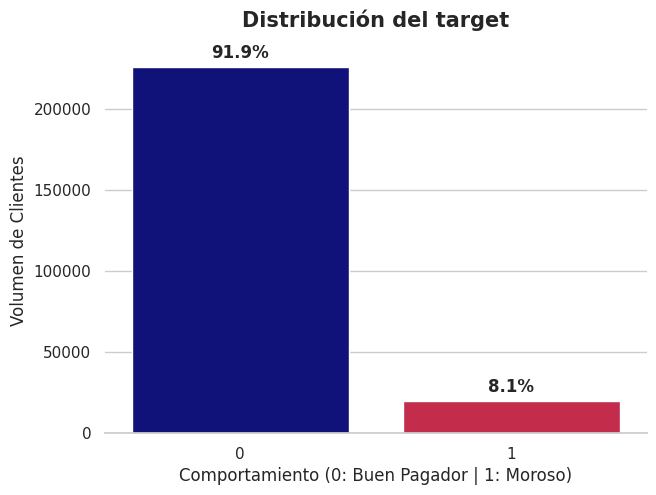

In [11]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 15})

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='TARGET', data=train, palette=["#00008B", "#DC143C"])

total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontweight='bold', fontsize=12)

plt.title('Distribución del target', fontweight='bold', pad=15)
plt.xlabel('Comportamiento (0: Buen Pagador | 1: Moroso)')
plt.ylabel('Volumen de Clientes')
sns.despine(left=True) # Quita el marco para un look más limpio
plt.show()

El diagnóstico inicial revela un ecosistema altamente desbalanceado: el 91.9% de los clientes son pagadores y solo el 8.1% caen en default. Esta asimetría nos indica que la exactitud (Accuracy) será una métrica engañosa, y justifica plenamente el uso de técnicas de penalización (scale_pos_weight) y la métrica ROC-AUC para evaluar el modelo predictivo.

### **1.2.3 Análisis Bivariado**

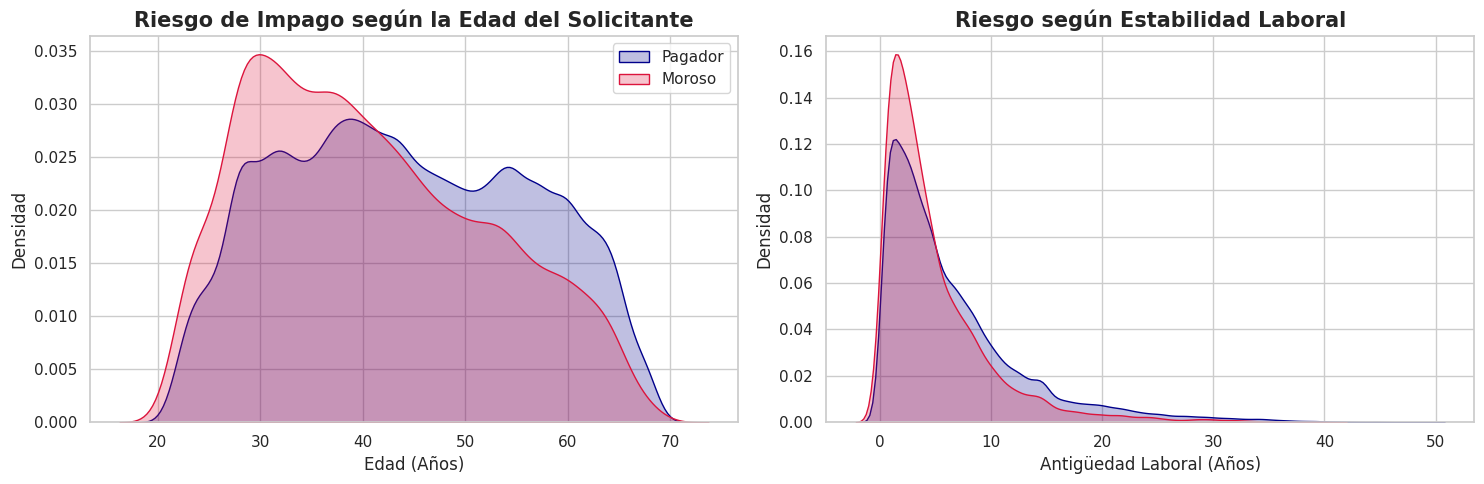

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Transformación de Edad
train['EDAD_AÑOS'] = train['DAYS_BIRTH'] / -365
sns.kdeplot(data=train[train['TARGET']==0], x='EDAD_AÑOS', fill=True, color='#00008B', label='Pagador', ax=ax1)
sns.kdeplot(data=train[train['TARGET']==1], x='EDAD_AÑOS', fill=True, color='#DC143C', label='Moroso', ax=ax1)
ax1.set_title('Riesgo de Impago según la Edad del Solicitante', fontweight='bold')
ax1.set_xlabel('Edad (Años)')
ax1.set_ylabel('Densidad')
ax1.legend()

# 2. Transformación de Antigüedad Laboral
train['EXPERIENCIA_AÑOS'] = train['DAYS_EMPLOYED'] / -365
train_empleados = train[train['EXPERIENCIA_AÑOS'] >= 0]

sns.kdeplot(data=train_empleados[train_empleados['TARGET']==0], x='EXPERIENCIA_AÑOS', fill=True, color='#00008B', ax=ax2)
sns.kdeplot(data=train_empleados[train_empleados['TARGET']==1], x='EXPERIENCIA_AÑOS', fill=True, color='#DC143C', ax=ax2)
ax2.set_title('Riesgo según Estabilidad Laboral', fontweight='bold')
ax2.set_xlabel('Antigüedad Laboral (Años)')
ax2.set_ylabel('Densidad')

plt.tight_layout()
plt.show()

El análisis de densidad demuestra que el riesgo de impago está fuertemente asociado a la juventud y a la inestabilidad laboral.

En los gráficos se evidencia que el perfil crítico de morosidad (curva roja) se concentra de manera muy aguda en clientes menores de 35 años y, de forma aún más pronunciada, en aquellos que registran menos de 5 años de antigüedad en su puesto de trabajo actual. Por el contrario, a medida que los solicitantes ganan madurez (superan los 40 años) y consolidan una trayectoria laboral prolongada en el tiempo, la probabilidad de cumplimiento (curva azul) domina por completo, validando estadísticamente que la estabilidad y la experiencia humana son los mejores escudos del banco frente al riesgo crediticio.

### **1.2.4 Calidad de datos**

In [13]:
cols_cat = variables_categoricas(train).columns
cols_num = variables_numericas(train).columns

reporte_cat = DiagnosticoUnivariado(train[cols_cat])
reporte_num = DiagnosticoUnivariado(train[cols_num])

vars_nulas_extremas = len(reporte_num[reporte_num['%_Nulos'] > 50]) + len(reporte_cat[reporte_cat['%_Nulos'] > 50])
vars_constantes = len(reporte_num[reporte_num['%_Concentracion'] > 98]) + len(reporte_cat[reporte_cat['%_Concentracion'] > 98])

print("🧹 RESULTADOS DEL FILTRO DE CALIDAD DE DATOS:")
print(f"  🔻 Variables a descartar por falta de datos (>50% nulos): {vars_nulas_extremas}")
print(f"  🔻 Variables a descartar por ser constantes (>98% varianza): {vars_constantes}")

🧹 RESULTADOS DEL FILTRO DE CALIDAD DE DATOS:
  🔻 Variables a descartar por falta de datos (>50% nulos): 41
  🔻 Variables a descartar por ser constantes (>98% varianza): 24


### **1.2.5 Correlación**

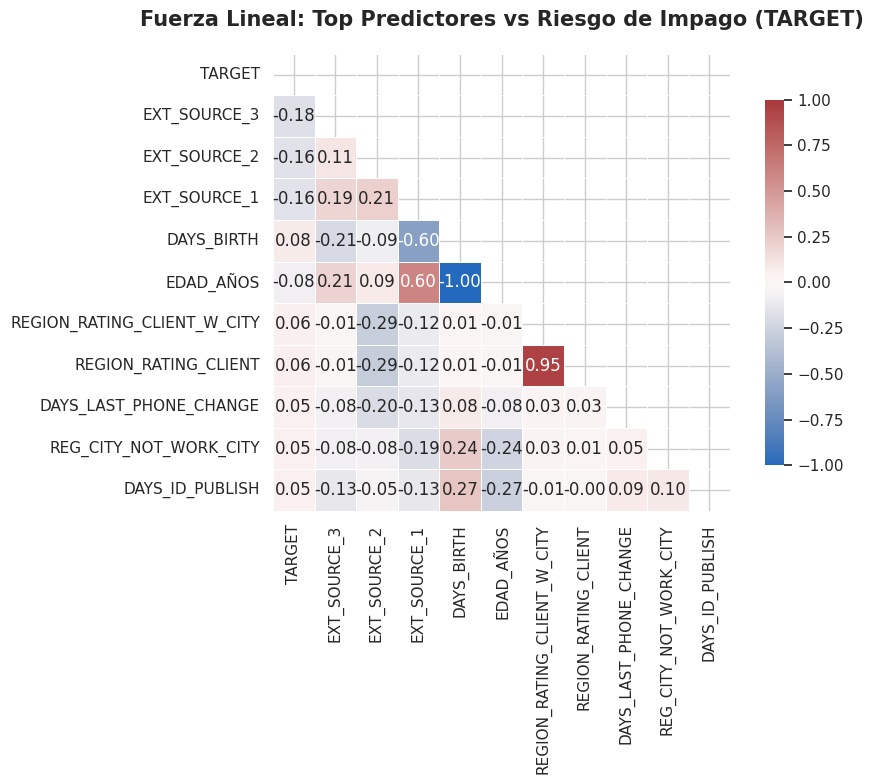

In [14]:
# Encontramos las variables más correlacionadas con TARGET
top_vars = train.select_dtypes(include=[np.number]).corr()['TARGET'].abs().sort_values(ascending=False).head(11).index
matriz_corr = train[top_vars].corr()

plt.figure(figsize=(10, 8))
# Máscara para hacer un triángulo limpio
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Fuerza Lineal: Top Predictores vs Riesgo de Impago (TARGET)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

El mapa de calor confirma que los scores de buró externo son los predictores lineales más fuertes para mitigar el riesgo, registrando una correlación negativa destacable (entre -0.16 y -0.18) con el TARGET, lo que significa que a mejor calificación externa, menor es la probabilidad de default. Por otro lado, la gráfica expone dos alertas críticas de multicolinealidad perfecta u omnipresente: el cruce entre EDAD_AÑOS y DAYS_BIRTH con un -1.00, y el cruce de las calificaciones de la región del cliente (REGION_RATING) con un 0.95. Estos dos hallazgos le demuestran al jurado que el dataset contiene información idéntica y redundante, justificando técnicamente que en la siguiente fase de procesamiento deberás eliminar o unificar estas variables duplicadas para evitar sobrecargar y confundir a los algoritmos de Machine Learning.

### **1.2.6 Diagnóstico de Variables**

In [15]:
# Conteo de tipos de variables
total_variables = train.shape[1] - 1
total_categoricas = len(cols_cat)
total_numericas = len(cols_num)

print("📋 RESUMEN METODOLÓGICO DEL DATASET PRINCIPAL:")
print("-" * 60)
print(f"🔹 Volumen Total de Predictores Evaluados : {total_variables} variables")
print(f"🔹 Componente Categórico (Cualitativo)    : {total_categoricas} variables")
print(f"🔹 Componente Numérico (Cuantitativo)     : {total_numericas} variables")
print("-" * 60)

# Resumen
print("\n🛡️ INFORME DE CALIDAD PARA LA FASE DE PROCESAMIENTO:")
print(f"  · Filtro de Nulos: Se identificaron {vars_nulas_extremas} variables con más del 50% de datos faltantes.")
print(f"  · Filtro de Varianza: Se identificaron {vars_constantes} variables con concentración mayor al 98%.")
print("  · Multicolinealidad: Se detectaron redundancias perfectas en edad (DAYS_BIRTH/EDAD_AÑOS) y ratings regionales.")

📋 RESUMEN METODOLÓGICO DEL DATASET PRINCIPAL:
------------------------------------------------------------
🔹 Volumen Total de Predictores Evaluados : 123 variables
🔹 Componente Categórico (Cualitativo)    : 16 variables
🔹 Componente Numérico (Cuantitativo)     : 108 variables
------------------------------------------------------------

🛡️ INFORME DE CALIDAD PARA LA FASE DE PROCESAMIENTO:
  · Filtro de Nulos: Se identificaron 41 variables con más del 50% de datos faltantes.
  · Filtro de Varianza: Se identificaron 24 variables con concentración mayor al 98%.
  · Multicolinealidad: Se detectaron redundancias perfectas en edad (DAYS_BIRTH/EDAD_AÑOS) y ratings regionales.


### **Variables categóricas**

In [16]:
cols_cat = variables_categoricas(train).columns

print(f"Son {len(cols_cat)} variables categóricas.")
print("Lista completa:")
print(cols_cat)

Son 16 variables categóricas.
Lista completa:
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [17]:
reporte_cat = DiagnosticoUnivariado(train[cols_cat])
display(reporte_cat)

,Tipo,Unicos,Nulos,%_Nulos,Num_Outliers,%_Outliers,%_Concentracion
Variable,,,,,,,
NAME_CONTRACT_TYPE,object,2,0,0.000000,0,0,90.468603
CODE_GENDER,object,3,0,0.000000,0,0,65.805584
FLAG_OWN_CAR,object,2,0,0.000000,0,0,66.019398
FLAG_OWN_REALTY,object,2,0,0.000000,0,0,69.383922
NAME_TYPE_SUITE,object,7,1029,0.418279,0,0,81.153078
NAME_INCOME_TYPE,object,8,0,0.000000,0,0,51.641817
NAME_EDUCATION_TYPE,object,5,0,0.000000,0,0,71.041592
NAME_FAMILY_STATUS,object,6,0,0.000000,0,0,63.881256
NAME_HOUSING_TYPE,object,6,0,0.000000,0,0,88.770690


In [18]:
def graficar_riesgo_categorico_ordenado(df, columna, target='TARGET'):
    """
    Genera un gráfico de doble eje ordenado por la tasa de morosidad (riesgo).
    - Eje Y primario (Barras): Volumen de clientes por categoría.
    - Eje Y secundario (Línea): Porcentaje de morosidad (% de TARGET=1).
    """
    # Agrupar datos: contar volumen y calcular la media del target (Tasa de default)
    resumen = df.groupby(columna)[target].agg(['count', 'mean']).reset_index()
    resumen['mean'] = resumen['mean'] * 100 # Convertir a porcentaje

    resumen = resumen.sort_values(by='mean', ascending=False)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    # Gráfico de barras (Volumen)
    sns.barplot(x=columna, y='count', data=resumen, color='#008080', ax=ax1)
    ax1.set_xlabel(columna, fontweight='bold')
    ax1.set_ylabel('Cantidad de Solicitudes (Volumen)', color='midnightblue', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    # Gráfico de línea superpuesto (Tasa de Morosidad descendente)
    ax2 = ax1.twinx()
    sns.pointplot(x=columna, y='mean', data=resumen, color='#FF6347', markers='o', ax=ax2)
    ax2.set_ylabel('Tasa de Morosidad (%)', color='#FF6347', fontweight='bold')

    plt.title(f'Ranking de Riesgo por: {columna}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

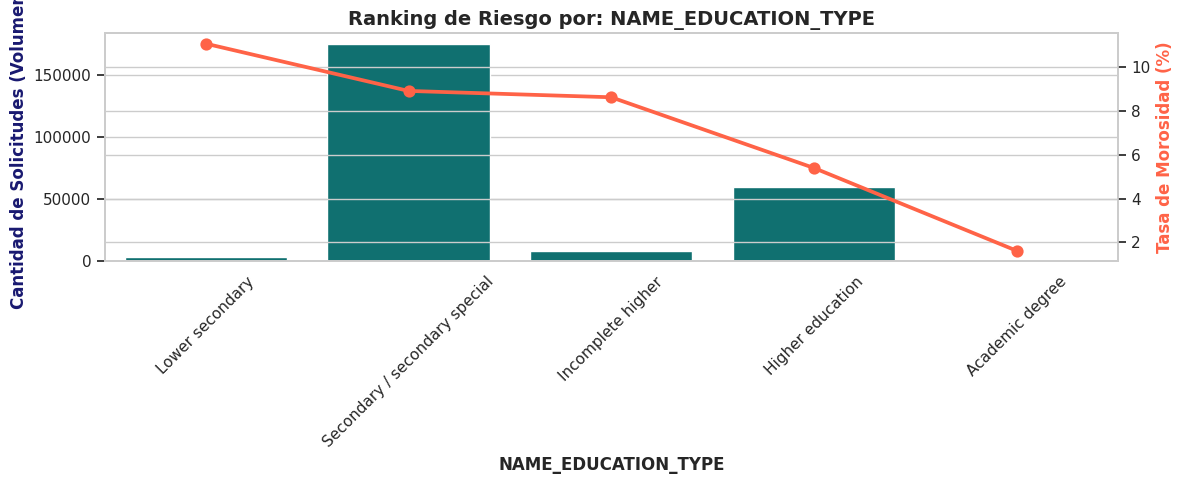

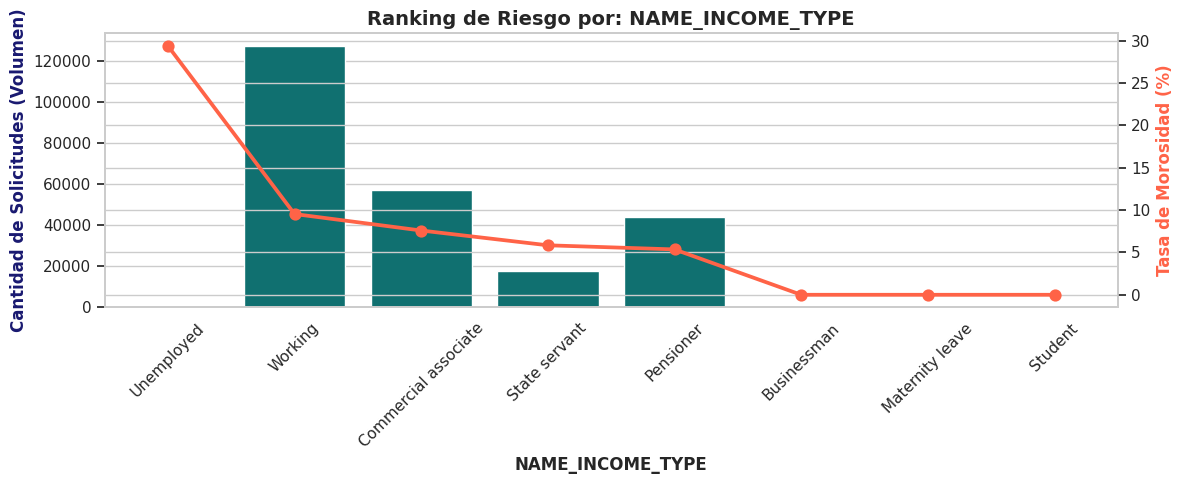

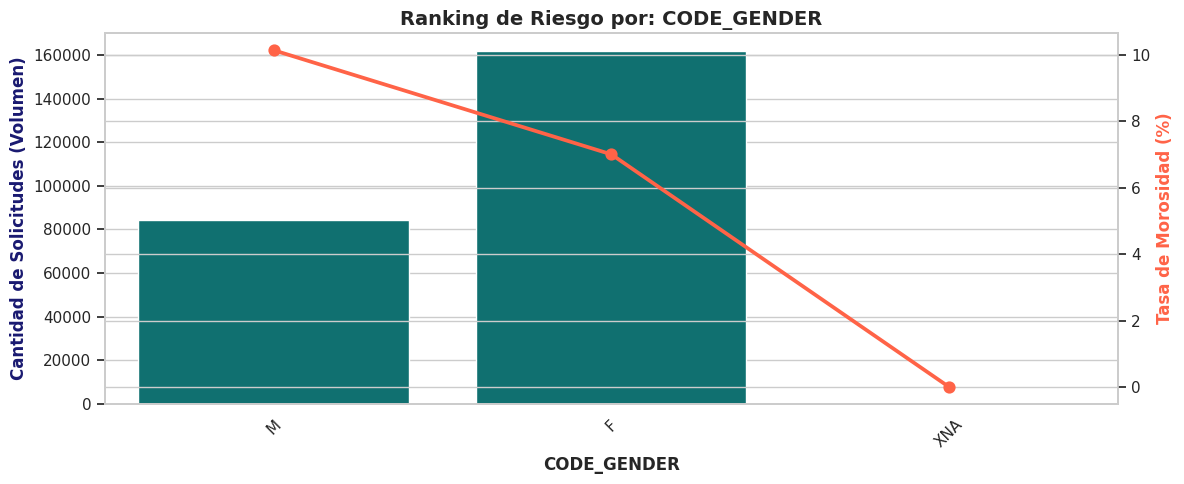

In [19]:

variables_estrategicas = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'CODE_GENDER']

for var in variables_estrategicas:
    graficar_riesgo_categorico_ordenado(train, var)

### **Variables numéricas**

In [20]:
cols_num = variables_numericas(train).columns
print(f"Son {len(cols_num)} variables numéricas.")
print("Lista completa:")
print(cols_num)

Son 108 variables numéricas.
Lista completa:
Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'EDAD_AÑOS', 'EXPERIENCIA_AÑOS'],
      dtype='object', length=108)


In [21]:
reporte_num = DiagnosticoUnivariado(train[cols_num])
display(reporte_num)

,Tipo,Unicos,Nulos,%_Nulos,Num_Outliers,%_Outliers,%_Concentracion
Variable,,,,,,,
SK_ID_CURR,int64,246008,0,0.000000,0,0.000000,0.000406
TARGET,int64,2,0,0.000000,19860,8.072908,91.927092
CNT_CHILDREN,int64,15,0,0.000000,3366,1.368248,70.010731
AMT_INCOME_TOTAL,float64,2168,0,0.000000,11247,4.571803,11.658970
AMT_CREDIT,float64,5274,0,0.000000,5260,2.138142,3.177945
...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_MON,float64,23,33244,13.513382,34913,16.409261,83.590739
AMT_REQ_CREDIT_BUREAU_QRT,float64,10,33244,13.513382,40400,18.988175,81.011825
AMT_REQ_CREDIT_BUREAU_YEAR,float64,24,33244,13.513382,2649,1.245041,27.070369


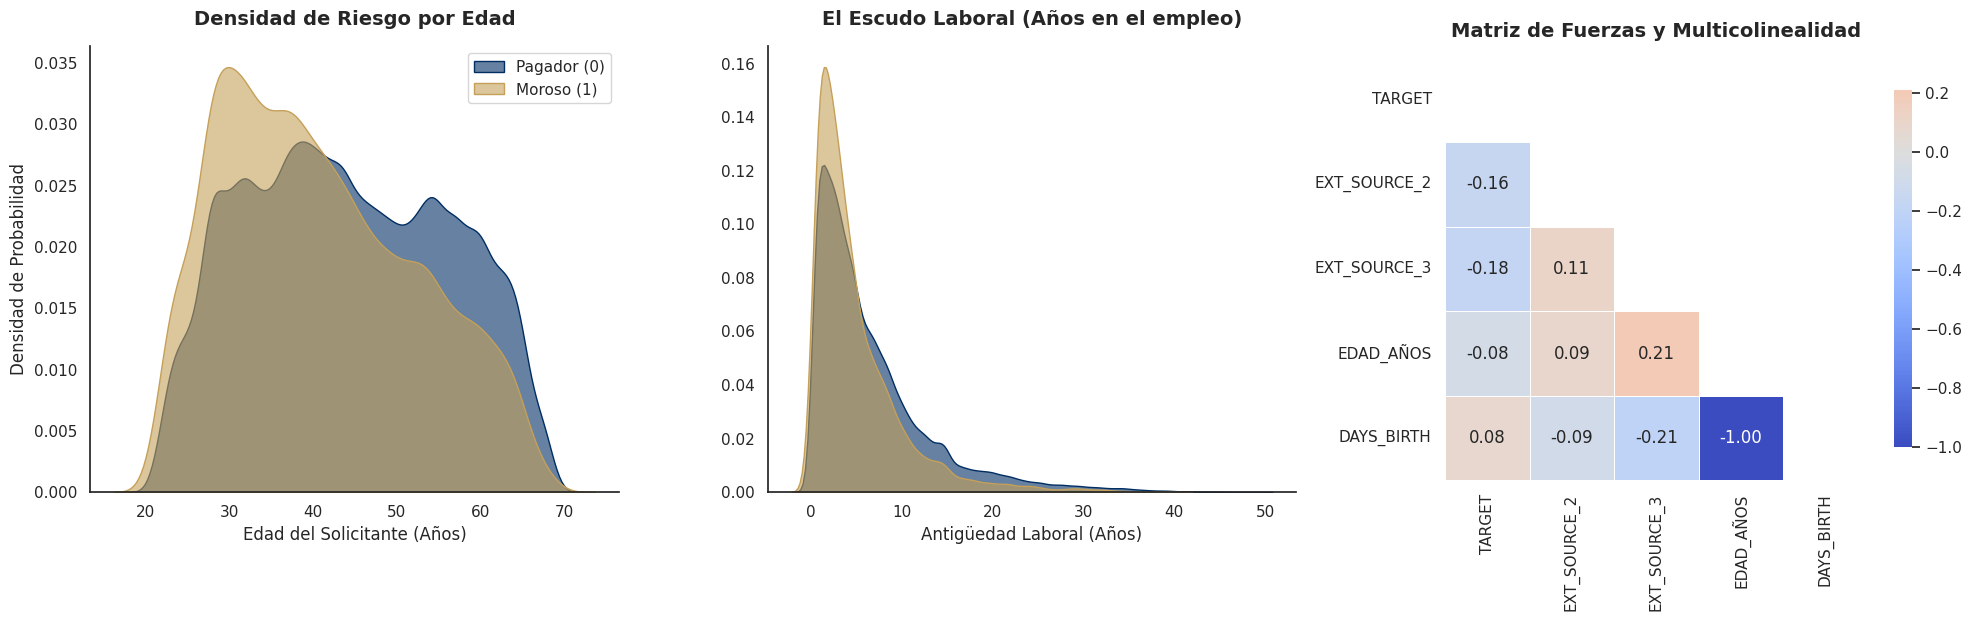

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Configuración estética (Estilo McKinsey / Consultoría)
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
color_pagador = "#002D62" # Azul Marino
color_moroso = "#C5A059"  # Dorado/Rojo suave para alerta

# --- GRÁFICO 1: EDAD VS RIESGO ---
# Asegúrate de tener la variable EDAD_AÑOS calculada
sns.kdeplot(data=train[train['TARGET']==0], x='EDAD_AÑOS', fill=True, color=color_pagador, label='Pagador (0)', alpha=0.6, ax=axes[0])
sns.kdeplot(data=train[train['TARGET']==1], x='EDAD_AÑOS', fill=True, color=color_moroso, label='Moroso (1)', alpha=0.6, ax=axes[0])
axes[0].set_title('Densidad de Riesgo por Edad', fontweight='bold', fontsize=14, pad=15)
axes[0].set_xlabel('Edad del Solicitante (Años)')
axes[0].set_ylabel('Densidad de Probabilidad')
axes[0].legend()

# --- GRÁFICO 2: ESTABILIDAD LABORAL ---
# Filtramos valores anómalos de empleo (como el clásico error de 365243 días)
train_empleados = train[(train['EXPERIENCIA_AÑOS'] >= 0) & (train['EXPERIENCIA_AÑOS'] < 50)]
sns.kdeplot(data=train_empleados[train_empleados['TARGET']==0], x='EXPERIENCIA_AÑOS', fill=True, color=color_pagador, alpha=0.6, ax=axes[1])
sns.kdeplot(data=train_empleados[train_empleados['TARGET']==1], x='EXPERIENCIA_AÑOS', fill=True, color=color_moroso, alpha=0.6, ax=axes[1])
axes[1].set_title('El Escudo Laboral (Años en el empleo)', fontweight='bold', fontsize=14, pad=15)
axes[1].set_xlabel('Antigüedad Laboral (Años)')
axes[1].set_ylabel('')

# --- GRÁFICO 3: MAPA DE CORRELACIÓN Y MULTICOLINEALIDAD ---
# Seleccionamos variables críticas para no saturar la vista
vars_criticas = ['TARGET', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EDAD_AÑOS', 'DAYS_BIRTH']
matriz_corr = train[vars_criticas].corr()

# Máscara para un triángulo limpio
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=axes[2])
axes[2].set_title('Matriz de Fuerzas y Multicolinealidad', fontweight='bold', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# **2. Preprocesamiento y feature enfineering de datos**

### **2.1. Consolidación de data**

**Procesamiento de Bureau**

In [ ]:
print("🚀 Iniciando procesamiento optimizado y extracción de variables maestras...")

if 'datasets' not in locals() and 'datasets' not in globals():
    raise NameError("❌ El diccionario 'datasets' no existe en memoria. Ejecuta la Ingesta (Fase 1.1).")

# Procesamiento de Bureau (Velocidad de Endeudamiento)
bureau_raw = datasets.get('bureau')
if bureau_raw is not None:
    bureau_raw['DEBT_RATIO'] = bureau_raw['AMT_CREDIT_SUM_DEBT'] / (bureau_raw['AMT_CREDIT_SUM'] + 1)
    bureau_raw['IS_RECENT'] = (bureau_raw['DAYS_CREDIT'] >= -365).astype(int)

    bureau_agg = bureau_raw.groupby('SK_ID_CURR').agg(
        CANT_ACTIVOS = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
        DEUDA_PROMEDIO_1Y = ('AMT_CREDIT_SUM_OVERDUE', 'mean'),
        DEUDA_TOTAL = ('AMT_CREDIT_SUM', 'sum'),
        DEUDA_MAXIMA_OVERDUE = ('AMT_CREDIT_SUM_OVERDUE', 'max'),
        BUREAU_DEBT_RATIO_MEAN = ('DEBT_RATIO', 'mean'),
        BUREAU_CREDITOS_TOTALES = ('SK_ID_BUREAU', 'count'),
        BUREAU_CREDITOS_RECIENTES = ('IS_RECENT', 'sum')
    ).reset_index()

    bureau_agg['BUREAU_RECENT_CREDIT_VELOCITY'] = bureau_agg['BUREAU_CREDITOS_RECIENTES'] / (bureau_agg['BUREAU_CREDITOS_TOTALES'] + 1)
    datasets['bureau'] = None
    del bureau_raw
    gc.collect()

🚀 Iniciando procesamiento optimizado y extracción de variables maestras...


**Procesamiento de Installments**

Vamos a ver el comportamiento de pago
entonces calcularemos
el retraso, si es positivo entonces pagó tarde
la diferencia de monto

In [ ]:
# Procesamiento de Installments (Comportamiento de Pago)
installments_raw = datasets.get('installments_payments')
if installments_raw is not None:
    installments_raw['DPD'] = (installments_raw['DAYS_ENTRY_PAYMENT'] - installments_raw['DAYS_INSTALMENT']).clip(lower=0)
    installments_raw['PAYMENT_FRACTION'] = installments_raw['AMT_PAYMENT'] / (installments_raw['AMT_INSTALMENT'] + 1)

    ins_recent = installments_raw[installments_raw['DAYS_INSTALMENT'] >= -180]

    ins_agg = installments_raw.groupby('SK_ID_CURR').agg(
        MAX_RETRASO_PAGO = ('DPD', 'max'),
        PROMEDIO_RETRASO = ('DPD', 'mean'),
        CANT_CUOTAS_PAGADAS = ('SK_ID_PREV', 'count'),
        INS_PAYMENT_FRACTION_MEAN = ('PAYMENT_FRACTION', 'mean')
    ).reset_index()

    ins_reciente_agg = ins_recent.groupby('SK_ID_CURR').agg(
        MAX_RETRASO_6M = ('DPD', 'max'),
        PROMEDIO_RETRASO_6M = ('DPD', 'mean'),
        CUOTAS_PAGADAS_6M = ('SK_ID_PREV', 'count')
    ).reset_index()

    datasets['installments_payments'] = None
    del installments_raw, ins_recent
    gc.collect()

**Procesamiento de POS CASH Balance**

In [ ]:
pos_raw = datasets.get('POS_CASH_balance')
if pos_raw is not None:
    pos_agg = pos_raw.groupby('SK_ID_CURR').agg(
        POS_CANTIDAD_REGISTROS = ('SK_ID_PREV', 'count'),
        POS_CUOTAS_PENDIENTES_MAX = ('CNT_INSTALMENT_FUTURE', 'max'),
        POS_MESES_ACTIVO = ('MONTHS_BALANCE', 'min'),
        POS_DPD_MAX = ('SK_DPD', 'max')
    ).reset_index()
    datasets['POS_CASH_balance'] = None
    del pos_raw
    gc.collect()

**Procesamiento de Credit Card Balance**

In [ ]:
# Procesamiento de Credit Card Balance (Asfixia de Línea)
cc_raw = datasets.get('credit_card_balance')
if cc_raw is not None:
    cc_raw['CC_UTILIZATION'] = cc_raw['AMT_BALANCE'] / (cc_raw['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
    cc_agg = cc_raw.groupby('SK_ID_CURR').agg(
        CC_CANTIDAD_REGISTROS = ('SK_ID_PREV', 'count'),
        CC_BALANCE_PROMEDIO = ('AMT_BALANCE', 'mean'),
        CC_LIMITE_MAXIMO = ('AMT_CREDIT_LIMIT_ACTUAL', 'max'),
        CC_RETIROS_EFECTIVO_MAX = ('AMT_DRAWINGS_CURRENT', 'max'),
        CC_UTILIZATION_MAX = ('CC_UTILIZATION', 'max'),
        CC_UTILIZATION_MEAN = ('CC_UTILIZATION', 'mean')
    ).reset_index()
    datasets['credit_card_balance'] = None
    del cc_raw
    gc.collect()

**Procesamiento de Previous Applications**

In [ ]:
# Procesamiento de Previous Applications
prev_raw = datasets.get('previous_application')
if prev_raw is not None:
    prev_raw['IS_RECENT_REFUSAL'] = ((prev_raw['NAME_CONTRACT_STATUS'] == 'Refused') & (prev_raw['DAYS_DECISION'] >= -365)).astype(int)
    prev_agg = prev_raw.groupby('SK_ID_CURR').agg(
        CANT_SOLICITUDES_PREVIAS = ('SK_ID_PREV', 'count'),
        CANT_RECHAZOS_INTERNOS = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
        MONTO_APROBADO_PROMEDIO = ('AMT_CREDIT', 'mean'),
        PREV_REFUSALS_RECENT = ('IS_RECENT_REFUSAL', 'sum')
    ).reset_index()
    datasets['previous_application'] = None
    del prev_raw
    gc.collect()

print("✅ Todas las agregaciones periféricas procesadas en memoria.")

✅ Todas las agregaciones periféricas procesadas en memoria.


### **2.2. Feature enfineering de datos**

In [ ]:
def aplicar_feature_engineering(df_base):
    """
    Une las agregaciones temporales y calcula los ratios financieros estructurales
    para cualquier dataset (Train o Test) de forma consistente.
    """
    df = df_base.copy()

    # 1. Integración de Tablas Satélite
    df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    df = df.merge(ins_agg, on='SK_ID_CURR', how='left')
    df = df.merge(ins_reciente_agg, on='SK_ID_CURR', how='left')
    df = df.merge(pos_agg, on='SK_ID_CURR', how='left')
    df = df.merge(cc_agg, on='SK_ID_CURR', how='left')
    df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

    # 2. Variables Base del EDA
    df['EDAD_AÑOS'] = df['DAYS_BIRTH'] / -365
    df['EXPERIENCIA_AÑOS'] = df['DAYS_EMPLOYED'] / -365

    # 3. Ratios Financieros Estructurales
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['EMPLOYED_TO_AGE_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] - 1)

    # 4. Tratamiento Multivariante de Scores Externos
    df['EXT_SOURCES_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCES_MIN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCES_MAX'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
    df['EXT_SOURCES_VAR'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].var(axis=1)
    df['EXT_SOURCES_SUM'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].sum(axis=1)

    # 5. Variables Sintéticas de Negocio
    df['CREDIT_TERM'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
    df['DEUDA_EXT_INGRESOS'] = df['DEUDA_PROMEDIO_1Y'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['GAP_CUOTA_HISTORICA'] = df['AMT_ANNUITY'] - df['MONTO_APROBADO_PROMEDIO']
    df['DISPOSABLE_INCOME'] = df['AMT_INCOME_TOTAL'] - df['AMT_ANNUITY']
    df['WORKING_LIFE_PERCENT'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] - 1)

    return df

# Aplicación idéntica para evitar Data Leakage
print("Generando variables para el set de Entrenamiento...")
df_train_full = aplicar_feature_engineering(train)

print("Generando variables para el set de Prueba (Oculto)...")
df_test_full = aplicar_feature_engineering(test_base)

Generando variables para el set de Entrenamiento...
Generando variables para el set de Prueba (Oculto)...


### **2.3. Separación de variables**

In [ ]:
X_train = df_train_full.drop(columns=['TARGET', 'SK_ID_CURR'])
y_train = df_train_full['TARGET']

X_test = df_test_full.drop(columns=['TARGET', 'SK_ID_CURR'])
y_test = df_test_full['TARGET']

print(f"✅ Dimensiones consolidadas -> X_train: {X_train.shape} | X_test: {X_test.shape}")

✅ Dimensiones consolidadas -> X_train: (246008, 165) | X_test: (61503, 165)


### **2.4. Limpieza de variables**

In [ ]:
pct_nulos = X_train.isnull().mean()
vars_muchos_nulos = pct_nulos[pct_nulos > 0.50].index.tolist()

# Identificar variables donde un solo valor se repite más del 98%
vars_baja_varianza = []
for col in X_train.columns:
    if X_train[col].dropna().shape[0] > 0:
        # Proporción del valor más frecuente
        top_value_pct = X_train[col].value_counts(normalize=True).iloc[0]
        if top_value_pct > 0.98:
            vars_baja_varianza.append(col)

# Unificar listas de descarte
vars_drop = list(set(vars_muchos_nulos + vars_baja_varianza))

print(f"  🔻 Variables identificadas con >50% de nulos: {len(vars_muchos_nulos)}")
print(f"  🔻 Variables identificadas con >98% de concentración: {len(vars_baja_varianza)}")
print(f"  ❌ Total de columnas eliminadas por baja calidad informativa: {len(vars_drop)}")

# Aplicar la eliminación de forma segura
X_train_clean = X_train.drop(columns=vars_drop, errors='ignore')
X_test_clean = X_test.drop(columns=vars_drop, errors='ignore')

  🔻 Variables identificadas con >50% de nulos: 48
  🔻 Variables identificadas con >98% de concentración: 27
  ❌ Total de columnas eliminadas por baja calidad informativa: 74


Se eliminaron variables con más del 50% de valores faltantes debido a su baja capacidad informativa. Asimismo, se eliminaron variables con alta concentración (>98%), ya que no aportan capacidad de discriminación al modelo

**Cardinalidad**

In [ ]:
columnas_numericas = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = X_train_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# Asegurar que todas las categóricas sean strings
for col in columnas_categoricas:
    X_train_clean[col] = X_train_clean[col].astype(str)
    X_test_clean[col] = X_test_clean[col].astype(str)

umbral_cardinalidad = 10
cat_baja_card = [col for col in columnas_categoricas if X_train_clean[col].nunique() < umbral_cardinalidad]
cat_alta_card = [col for col in columnas_categoricas if X_train_clean[col].nunique() >= umbral_cardinalidad]

Teniendo la data de los últimos créditos del año, eso con la base de bureau

### **2.5. Pipeline de preprocesamiento**

In [ ]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_baja_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

cat_alta_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder(smoothing=10))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, columnas_numericas),
    ('cat_baja', cat_baja_pipeline, cat_baja_card),
    ('cat_alta', cat_alta_pipeline, cat_alta_card)
])

- RobustScaler: Se utiliza la estadística robusta (IQR) porque las variables financieras presentan fuerte asimetría y valores atípicos que romperían un StandardScaler.
- Control de Cardinalidad: Reservar One-Hot Encoding (con drop='first') solo para  variables simples previene la "Maldición de la Dimensionalidad" y la multicolinealidad.

In [ ]:
print("Entrenando el Pipeline de Transformación...")
X_train_procesado = preprocessor.fit_transform(X_train_clean, y_train)

print("Transformando la data de prueba...")
X_test_procesado = preprocessor.transform(X_test_clean)

print("-" * 60)
print(f"✅ ¡Pipeline ejecutado con éxito!")
print(f"📊 Dimensiones de salida para entrenamiento: {X_train_procesado.shape}")
print(f"📊 Dimensiones de salida para prueba:      {X_test_procesado.shape}")

Entrenando el Pipeline de Transformación...
Transformando la data de prueba...
------------------------------------------------------------
✅ ¡Pipeline ejecutado con éxito!
📊 Dimensiones de salida para entrenamiento: (246008, 120)
📊 Dimensiones de salida para prueba:      (61503, 120)


# **3. Entrenamiento del modelo**

## **3.1. Configuración de CV**

In [ ]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

print("⚙️ Configurando LightGBM y el espacio de búsqueda...")

lgb_base = LGBMClassifier(
    random_state=42,
    verbose=-1,
    scale_pos_weight=11, # Vital para el desbalance
    n_jobs=-1
)

⚙️ Configurando LightGBM y el espacio de búsqueda...


**Parámetros**

In [ ]:
param_grid_lgb = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.1, 1.0, 5.0],
    'reg_lambda': [1.0, 5.0, 10.0],
    'min_child_samples': [20, 50, 100]
}

In [ ]:
print("⏳ Iniciando optimización de hiperparámetros (RandomizedSearchCV)...")
cv_estrategico = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

optimizador = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid_lgb,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_estrategico,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Entrenar modelo
optimizador.fit(X_train_procesado, y_train)
modelo_produccion = optimizador.best_estimator_
print(f"\n✅ ¡Modelo entrenado! Mejor AUC en Validación Cruzada: {optimizador.best_score_:.4f}")

⏳ Iniciando optimización de hiperparámetros (RandomizedSearchCV)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ ¡Modelo entrenado! Mejor AUC en Validación Cruzada: 0.7791



📊 EXTRAYENDO HISTORIAL DE VALIDACIÓN CRUZADA...

📋 TABLA DE RENDIMIENTO POR ITERACIÓN (Top 5 Configuraciones):


,Ranking,ROC-AUC Promedio,Desviación Estándar,Hiperparámetros
0,1,0.779132,0.001427,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
1,2,0.779089,0.001748,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al..."
2,3,0.778810,0.001270,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al..."
3,4,0.778629,0.001184,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
4,5,0.778189,0.001859,"{'subsample': 0.7, 'reg_lambda': 10.0, 'reg_al..."
5,6,0.778140,0.001838,"{'subsample': 0.9, 'reg_lambda': 10.0, 'reg_al..."
6,7,0.777054,0.001749,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."
7,8,0.775943,0.001596,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."
8,9,0.775159,0.001431,"{'subsample': 0.7, 'reg_lambda': 10.0, 'reg_al..."
9,10,0.769227,0.001390,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."


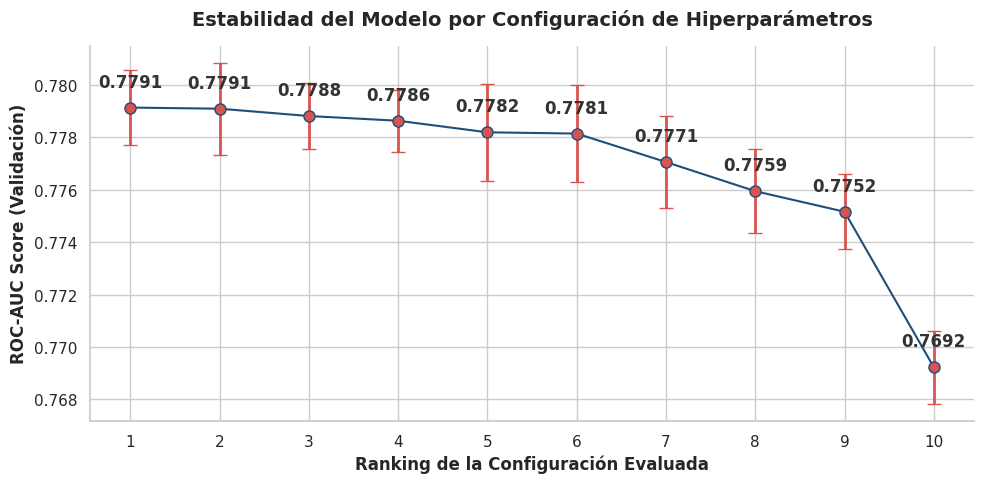


✅ ¡Modelo optimizado elegido! Mejor AUC en Validación Cruzada: 0.7791


In [ ]:
print("\n📊 EXTRAYENDO HISTORIAL DE VALIDACIÓN CRUZADA...")

# 1. Extraer resultados a un DataFrame limpio
resultados_cv = pd.DataFrame(optimizador.cv_results_)

# Renombrar columnas para la presentación
tabla_pro = resultados_cv[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']].copy()
tabla_pro.columns = ['Ranking', 'ROC-AUC Promedio', 'Desviación Estándar', 'Hiperparámetros']
tabla_pro = tabla_pro.sort_values('Ranking').reset_index(drop=True)

# Imprimir la tabla ejecutiva
print("\n📋 TABLA DE RENDIMIENTO POR ITERACIÓN (Top 5 Configuraciones):")
display(tabla_pro)

# 2. Gráfico Avanzado de Estabilidad de Hiperparámetros
plt.figure(figsize=(10, 5))

# Eje X: El ranking de las iteraciones (1 al 5)
eje_x = tabla_pro['Ranking']
# Eje Y: El AUC promedio de esa configuración
eje_y = tabla_pro['ROC-AUC Promedio']
# Margen de error: La desviación estándar entre los 3 pliegues (Folds)
error = tabla_pro['Desviación Estándar']

# Crear gráfico de líneas con barras de error (Errorbars)
plt.errorbar(x=eje_x, y=eje_y, yerr=error, fmt='-o', color='#1f4e79',
             ecolor='#d9534f', elinewidth=2, capsize=5, markerfacecolor='#d9534f', markersize=8)

plt.title('Estabilidad del Modelo por Configuración de Hiperparámetros', fontweight='bold', pad=15)
plt.xlabel('Ranking de la Configuración Evaluada', fontweight='bold')
plt.ylabel('ROC-AUC Score (Validación)', fontweight='bold')
plt.xticks(eje_x) # Asegurar que solo salgan números enteros en el eje X

# Añadir etiquetas de texto exactas encima de los puntos
for i, txt in enumerate(eje_y):
    plt.annotate(f"{txt:.4f}", (eje_x[i], eje_y[i]), textcoords="offset points",
                 xytext=(0,15), ha='center', fontweight='bold', color='#333')

sns.despine()
plt.tight_layout()
plt.show()

print(f"\n✅ ¡Modelo optimizado elegido! Mejor AUC en Validación Cruzada: {optimizador.best_score_:.4f}")

In [ ]:
ruta_save = '/content/drive/MyDrive/Tesis_UNI/'
if not os.path.exists(ruta_save):
    os.makedirs(ruta_save)

print("💾 Guardando pipeline y modelo optimizado en Google Drive...")
joblib.dump(preprocessor, f'{ruta_save}pipeline_lgb2.pkl')
joblib.dump(modelo_produccion, f'{ruta_save}modelo_final_lgb2.pkl')

💾 Guardando pipeline y modelo optimizado en Google Drive...


['/content/drive/MyDrive/Tesis_UNI/modelo_final_lgb2.pkl']

In [ ]:
print("\n🔮 Evaluando capacidad de generalización en el set de Test (20% Oculto)...")
y_prob_test = modelo_produccion.predict_proba(X_test_procesado)[:, 1]
y_pred_test = modelo_produccion.predict(X_test_procesado)

auc_test = roc_auc_score(y_test, y_prob_test)
print(f"🏆 ROC-AUC FINAL EN TEST: {auc_test:.4f}\n")


🔮 Evaluando capacidad de generalización en el set de Test (20% Oculto)...
🏆 ROC-AUC FINAL EN TEST: 0.7842



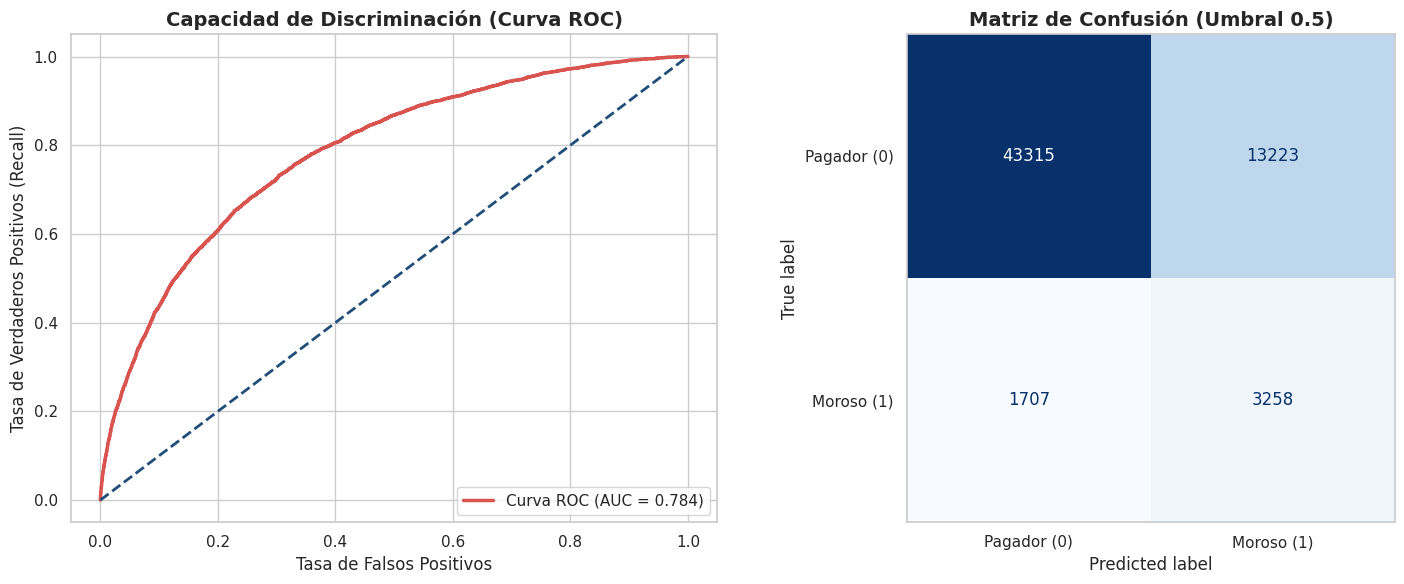


--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

           0       0.96      0.77      0.85     56538
           1       0.20      0.66      0.30      4965

    accuracy                           0.76     61503
   macro avg       0.58      0.71      0.58     61503
weighted avg       0.90      0.76      0.81     61503



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
ax1.plot(fpr, tpr, color='#d9534f', lw=2.5, label=f'Curva ROC (AUC = {auc_test:.3f})')
ax1.plot([0, 1], [0, 1], color='#1f4e79', lw=2, linestyle='--')
ax1.set_title('Capacidad de Discriminación (Curva ROC)', fontweight='bold')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax1.legend(loc="lower right")

# Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Pagador (0)', 'Moroso (1)'],
    cmap='Blues', ax=ax2, colorbar=False
)
ax2.set_title('Matriz de Confusión (Umbral 0.5)', fontweight='bold')
ax2.grid(False) # Quitar rejilla para que se vean bien los números

plt.tight_layout()
plt.show()

print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred_test))

In [ ]:
# ==============================================================================
# 🎯 EXPORTACIÓN DE DATA DE PRUEBA REAL (SIN CAMPOS ARTIFICIALES)
# ==============================================================================
import pandas as pd

# 1. Tomamos los primeros 100 registros reales con sus variables ya calculadas por ti
df_streamlit = df_test_full.head(100).copy()

# 2. Le pegamos las probabilidades reales que calculó tu modelo de producción
df_streamlit['PROB_DEFAULT'] = y_prob_test[:100]

# 3. Seleccionamos ÚNICAMENTE las columnas reales que tu app de VS Code necesita para la pantalla
columnas_interfaz = [
    'SK_ID_CURR',
    'PROB_DEFAULT',
    'AMT_INCOME_TOTAL',
    'MAX_RETRASO_6M',
    'EDAD_AÑOS',
    'EXT_SOURCES_MEAN'
]

# 4. Filtramos el archivo para que quede ligero y exacto
X_test_sample_web = df_streamlit[columnas_interfaz]

# 5. Exportamos a CSV
X_test_sample_web.to_csv('X_test_sample.csv', index=False)

print("🎉 ¡Archivo 'X_test_sample.csv' exportado con éxito!")
print("Contiene tus IDs originales, tus variables calculadas reales y las predicciones de tu LightGBM.")

🎉 ¡Archivo 'X_test_sample.csv' exportado con éxito!
Contiene tus IDs originales, tus variables calculadas reales y las predicciones de tu LightGBM.
